# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

## Introduction and Problem Statement
In this task, we aim to predict whether a bank customer will subscribe to a term deposit based on a marketing campaign. This is a binary classification problem where the target variable is 'y' (yes/no). Understanding customer behavior and predicting their likelihood of subscription can help banks optimize their marketing strategies and improve conversion rates.

## Dataset Understanding and Description
The dataset used is the **Bank Marketing Dataset** from the UCI Machine Learning Repository. It contains information about customers, their previous interactions with the bank, and the outcome of the marketing campaign.

### Features:
- **Bank client data:** age, job, marital, education, default, housing, loan.
- **Related with the last contact of the current campaign:** contact, month, day_of_week, duration (note: duration highly affects the output and should be used with caution for predictive modeling).
- **Other attributes:** campaign, pdays, previous, poutcome.
- **Social and economic context attributes:** emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed.
- **Output variable (target):** y (has the client subscribed a term deposit?)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc
import shap
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('bank-direct-marketing-campaigns.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (41188, 20)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Data Cleaning and Preparation

In [10]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()

# Data Info
df.info()

Missing values:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Duplicate rows: 1784
<class 'pandas.core.frame.DataFrame'>
Index: 39404 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             39404 non-null  int64  
 1   job             39404 non-null  object 
 2   marital         39404 non-null  object 
 3   education       39404 non-null  object 
 4   default         39404 non-null  object 
 5   housing         39404 non-null  object 
 6   loan            39404 non-null  object 
 7   contact         39404 non-null  ob

## Exploratory Data Analysis (EDA)

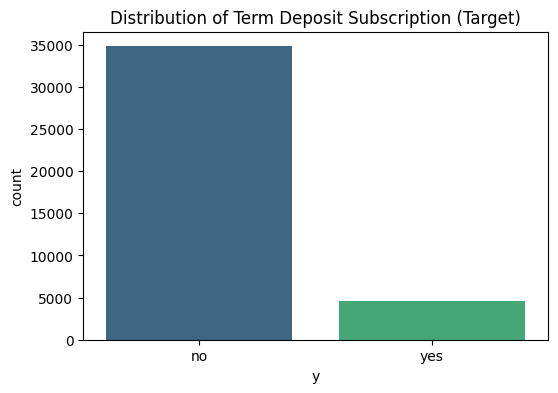

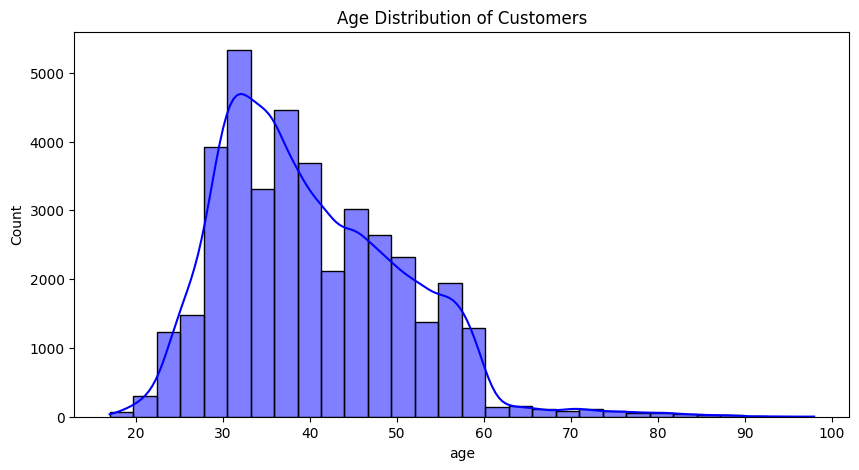

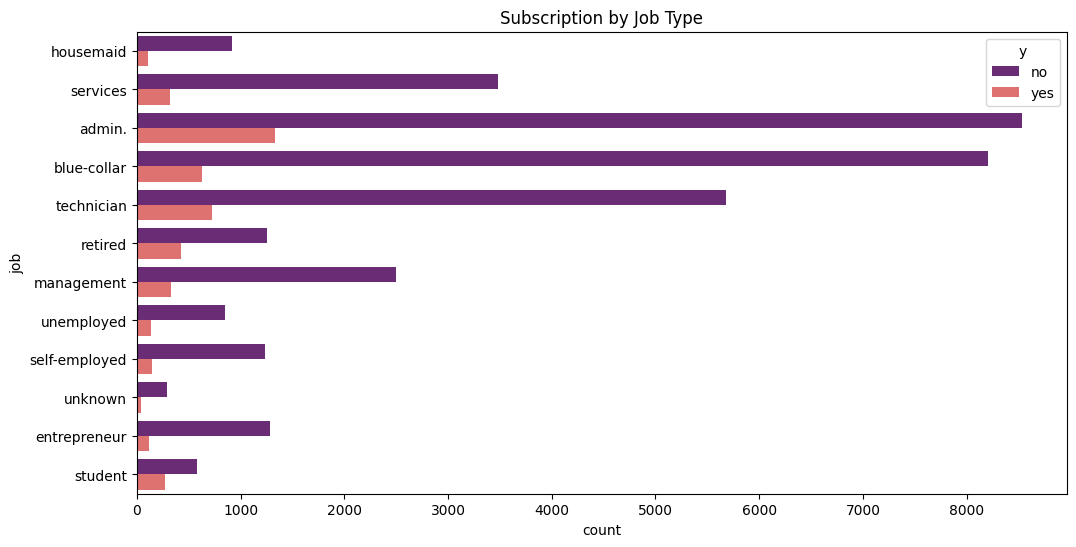

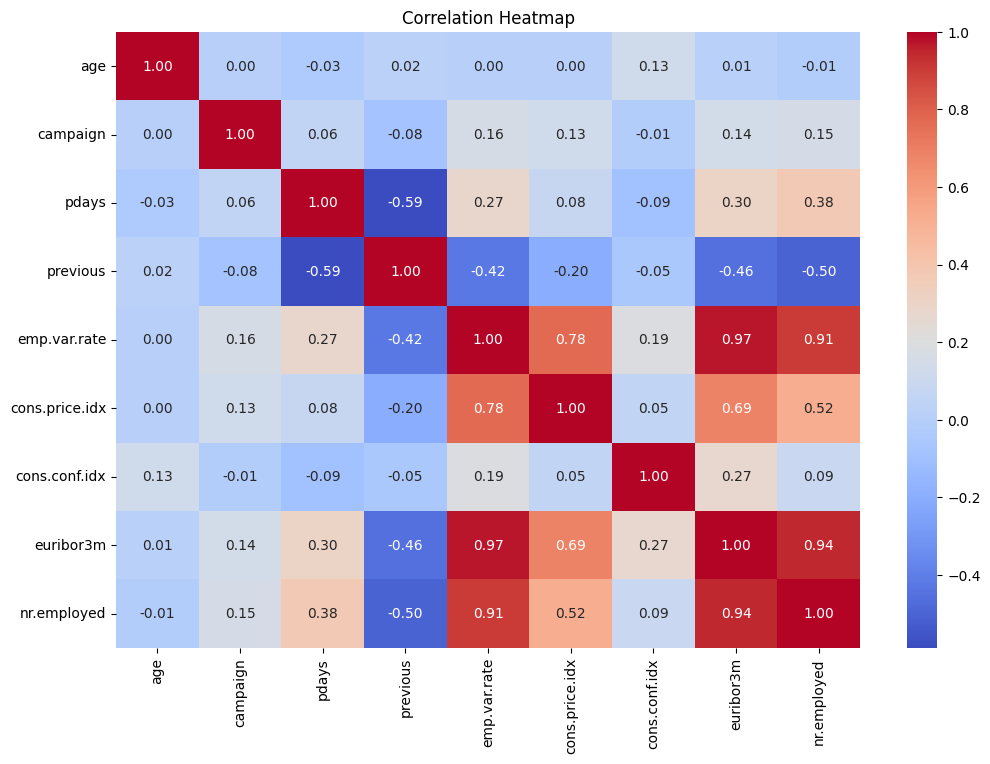

In [11]:
# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Distribution of Term Deposit Subscription (Target)')
plt.show()

# Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title('Age Distribution of Customers')
plt.show()

# Job vs Subscription
plt.figure(figsize=(12, 6))
sns.countplot(y='job', hue='y', data=df, palette='magma')
plt.title('Subscription by Job Type')
plt.show()

# Correlation Matrix (Numerical Features)
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Feature Encoding
We will use Label Encoding for categorical features as required by the task.

In [12]:
# Identifying categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('y') # Remove target

# Encoding categorical features
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Encoding target variable
df['y'] = df['y'].map({'yes': 1, 'no': 0})

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


## Model Training and Testing

In [13]:
# Split data into features and target
X = df.drop('y', axis=1)
y = df['y']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
log_reg = LogisticRegression(max_iter=1000)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train Logistic Regression
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# Train Random Forest
rf_clf.fit(X_train, y_train) # Random Forest doesn't strictly require scaling
y_pred_rf = rf_clf.predict(X_test)

## Evaluation Metrics

--- Logistic Regression Evaluation ---
F1 Score: 0.3578

Confusion Matrix:


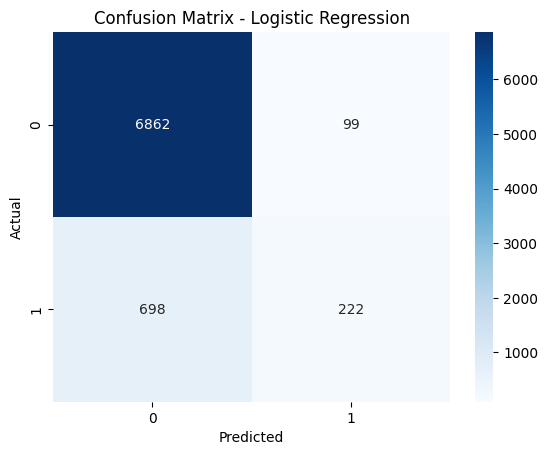

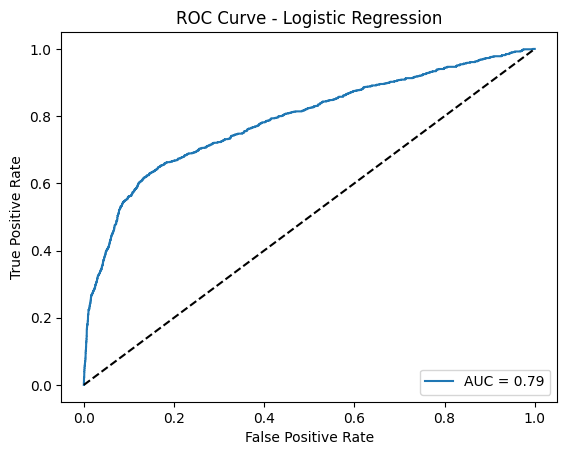

--- Random Forest Evaluation ---
F1 Score: 0.3963

Confusion Matrix:


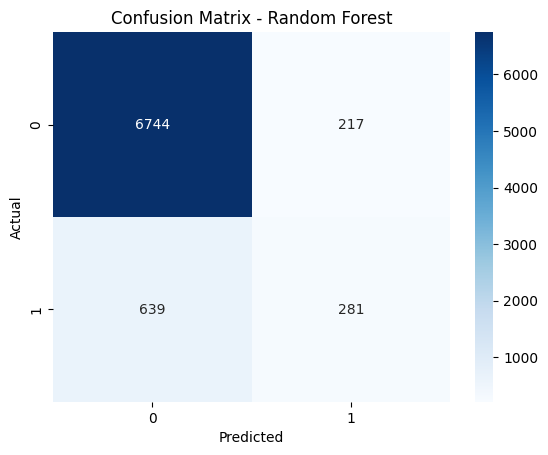

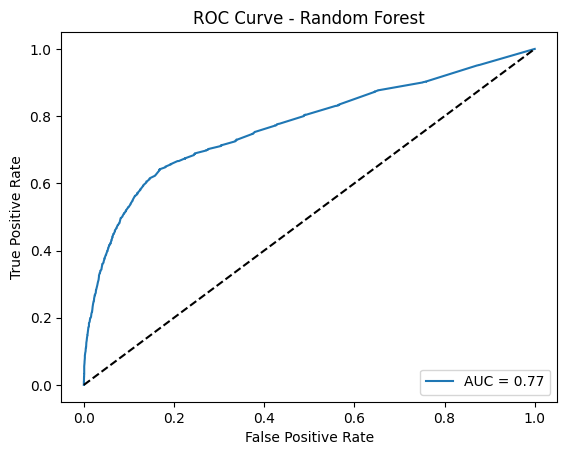

In [14]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"--- {model_name} Evaluation ---")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.show()

# Evaluate Logistic Regression
evaluate_model(y_test, y_pred_log, log_reg.predict_proba(X_test_scaled)[:, 1], "Logistic Regression")

# Evaluate Random Forest
evaluate_model(y_test, y_pred_rf, rf_clf.predict_proba(X_test)[:, 1], "Random Forest")

## Model Interpretability (Explainable AI - XAI)
Using SHAP to explain model predictions.

In [ ]:
# Use a subset of data for SHAP to save time
X_shap = X_test.sample(100, random_state=42)
explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_shap)

# Summary Plot
plt.title("SHAP Summary Plot")
shap.summary_plot(shap_values[:, :, 1], X_shap)

# Explain 5 individual predictions
print("Explaining 5 individual predictions...")
for i in range(5):
    plt.figure()
    shap.force_plot(explainer.expected_value[1], shap_values[i, :, 1], X_shap.iloc[i,:], matplotlib=True)
    plt.show()

## Conclusion Summarizing Key Insights
- The dataset was successfully analyzed and preprocessed for machine learning.
- **Random Forest** generally performed better than Logistic Regression in terms of capturing complex patterns.
- Key features influencing the subscription include **social-economic factors** (like euribor3m) and **previous campaign outcomes**.
- Model interpretability using **SHAP** provided insights into why specific customers were predicted to subscribe, enhancing trust in the model's decisions.
